In [28]:
import pathlib

current_dir = pathlib.Path().parent.resolve()
new_folder_path = current_dir / "plots"
new_folder_path.mkdir(parents=True, exist_ok=True)

In [29]:
import os

os.environ["JAX_PLATFORMS"] = "cpu"

import jax
import jax.numpy as jnp
import numpy as np
import mujoco
import mediapy as media
import pathlib

from kandel.utility.checkpoint_loader import load_policy
from kandel.utility.checkpoint_loader import load_playground_environment
from kandel.utility import running_statistics

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import scienceplots  # noqa: F401

plt.style.use(["science", "grid"])

In [30]:
episode_length = 1000

### Quadruped Locomotion with Limit Cycle Attractor in Weight Space

In [31]:
checkpoint_directory = "/home/alexanderdittrich/Downloads/xebec/250916194435-go1walkflatterrain-mlp-hebbian-openai-es-8/"
checkpoint = 499
policy_id = 0

policy, policy_params_init = load_policy(
    checkpoint_directory, checkpoint, policy_id
)
env, norm_state, cfg = load_playground_environment(
    checkpoint_directory, checkpoint
)

# Somehow this calls and error.
norm_state = norm_state.replace(count=0)

# Vectorized environment functions
env_reset_fcn = jax.jit(env.reset)
env_step_fcn = jax.jit(env.step)

# Vectorized environment and policy functions
policy_forward_fcn = jax.jit(policy.forward)
policy_update_fcn = jax.jit(policy.update)
policy_reset_fcn = jax.jit(policy.reset)

# Observation normalization
obs_normalize_fcn = jax.jit(running_statistics.normalize)

sim_interval = cfg.simulation_interval
update_interval = cfg.update_interval

total_time = cfg.rollout_length * sim_interval
total_steps = int(total_time / min(sim_interval, update_interval))

sim_steps = cfg.rollout_length
update_steps = int(total_time / update_interval)

relative_sim_steps = int(total_steps / sim_steps)
relative_update_steps = int(total_steps / update_steps)

In [32]:
seed = 0
key = jax.random.key(seed)
env_state = env_reset_fcn(key)

rollout_lca = []
policy_params_hist_lca = [policy_params_init]
policy_params = policy_params_init
for t in range(episode_length):
    if t % relative_sim_steps == 0:
        obs = obs_normalize_fcn(env_state.obs, norm_state)
        policy_params, actions = policy_forward_fcn(policy_params, obs)
        actions = jnp.clip(actions, cfg.action_clip_min, cfg.action_clip_max)
        env_state = env_step_fcn(env_state, actions)

        # fill reward mask
        rollout_lca.append(env_state)

    if t % relative_update_steps == 0:
        policy_params = policy_update_fcn(policy_params)

    policy_params_hist_lca.append(policy_params)

acc_rewards = jnp.array([env_state.reward for env_state in rollout_lca])
acc_rewards = jnp.sum(acc_rewards)
print(acc_rewards)

23.444458


In [33]:
render_every = 1
fps = 1.0 / env.dt / render_every
traj = rollout_lca[::render_every]

scene_option = mujoco.MjvOption()
scene_option.geomgroup[2] = True
scene_option.geomgroup[3] = False
scene_option.flags[mujoco.mjtVisFlag.mjVIS_CONTACTPOINT] = False
scene_option.flags[mujoco.mjtVisFlag.mjVIS_PERTFORCE] = False

camera_names = [
    mujoco.mj_id2name(env.mj_model, mujoco.mjtObj.mjOBJ_CAMERA, i)
    for i in range(env.mj_model.ncam)
]
camera_names.append(0)
camera_names = [camera_names[0]]

for camera in camera_names:
    frames = env.render(
        traj, height=480, width=640, camera=camera, scene_option=scene_option
    )
    # media.show_video(frames, fps=fps)
    media.write_video("plots/go1walkflatterrain_lca.mp4", frames, fps=fps)

100%|██████████| 1000/1000 [00:01<00:00, 690.35it/s]


### Quadruped Locomotion with Fixed Point Attractor in Weight Space

In [34]:
checkpoint_directory = "/home/alexanderdittrich/Downloads/xebec/250916195330-go1walkflatterrain-mlp-hebbian-openai-es-10/"
checkpoint = 499
policy_id = 0

policy, policy_params_init = load_policy(
    checkpoint_directory, checkpoint, policy_id
)
env, norm_state, cfg = load_playground_environment(
    checkpoint_directory, checkpoint
)

# Somehow this calls and error.
norm_state = norm_state.replace(count=0)

# Vectorized environment functions
env_reset_fcn = jax.jit(env.reset)
env_step_fcn = jax.jit(env.step)

# Vectorized environment and policy functions
policy_forward_fcn = jax.jit(policy.forward)
policy_update_fcn = jax.jit(policy.update)
policy_reset_fcn = jax.jit(policy.reset)

# Observation normalization
obs_normalize_fcn = jax.jit(running_statistics.normalize)

sim_interval = cfg.simulation_interval
update_interval = cfg.update_interval

total_time = cfg.rollout_length * sim_interval
total_steps = int(total_time / min(sim_interval, update_interval))

sim_steps = cfg.rollout_length
update_steps = int(total_time / update_interval)

relative_sim_steps = int(total_steps / sim_steps)
relative_update_steps = int(total_steps / update_steps)

In [35]:
seed = 0
key = jax.random.key(seed)
env_state = env_reset_fcn(key)

rollout_fpa = []
policy_params_hist_fpa = [policy_params_init]
policy_params = policy_params_init
for t in range(episode_length):
    if t % relative_sim_steps == 0:
        obs = obs_normalize_fcn(env_state.obs, norm_state)
        policy_params, actions = policy_forward_fcn(policy_params, obs)
        actions = jnp.clip(actions, cfg.action_clip_min, cfg.action_clip_max)
        env_state = env_step_fcn(env_state, actions)

        # fill reward mask
        rollout_fpa.append(env_state)

    if t % relative_update_steps == 0:
        policy_params = policy_update_fcn(policy_params)

    policy_params_hist_fpa.append(policy_params)

acc_rewards = jnp.array([env_state.reward for env_state in rollout_fpa])
acc_rewards = jnp.sum(acc_rewards)
print(acc_rewards)

23.47885


In [36]:
render_every = 1
fps = 1.0 / env.dt / render_every
traj = rollout_fpa[::render_every]

scene_option = mujoco.MjvOption()
scene_option.geomgroup[2] = True
scene_option.geomgroup[3] = False
scene_option.flags[mujoco.mjtVisFlag.mjVIS_CONTACTPOINT] = False
scene_option.flags[mujoco.mjtVisFlag.mjVIS_PERTFORCE] = False

camera_names = [
    mujoco.mj_id2name(env.mj_model, mujoco.mjtObj.mjOBJ_CAMERA, i)
    for i in range(env.mj_model.ncam)
]
camera_names.append(0)
camera_names = [camera_names[0]]

for camera in camera_names:
    frames = env.render(
        traj, height=480, width=640, camera=camera, scene_option=scene_option
    )
    # media.show_video(frames, fps=fps)
    media.write_video("plots/go1walkflatterrain_fpa.mp4", frames, fps=fps)

100%|██████████| 1000/1000 [00:01<00:00, 625.71it/s]


### Visualization

/tmp/ipykernel_41424/405598717.py:83: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


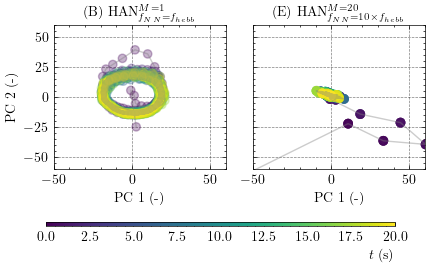

In [37]:
# PCA limit cycle attractor
pca = PCA(n_components=2)
scaler = StandardScaler()

flat_hist = []
for t in range(len(policy_params_hist_lca)):
    params = policy_params_hist_lca[t]["kernel_params"]["layer_0"][
        "W"
    ].flatten()
    flat_hist.append(params)

flat_hist = np.array(flat_hist)
flat_hist = scaler.fit_transform(flat_hist)
pca_history_lca = pca.fit_transform(flat_hist)

# PCA fixed-point attractor
pca = PCA(n_components=2)
scaler = StandardScaler()

flat_hist = []
for t in range(len(policy_params_hist_fpa)):
    params = policy_params_hist_fpa[t]["kernel_params"]["layer_0"][
        "W"
    ].flatten()
    flat_hist.append(params)

flat_hist = np.array(flat_hist)
flat_hist = scaler.fit_transform(flat_hist)
pca_history_fpa = pca.fit_transform(flat_hist)

# Plotting weights
t = np.arange(episode_length + 1) * env.dt

fig, axs = plt.subplots(1, 2, figsize=(4.5, 3.0), sharey=True, sharex=True)
cmap = cm.viridis
norm = mcolors.Normalize(vmin=t[0], vmax=t[-1])

for i, pca_history in enumerate([pca_history_lca, pca_history_fpa]):
    axs[i].plot(
        pca_history[:, 0],
        pca_history[:, 1],
        # pca_history[:, 2],
        color="grey",
        alpha=0.4,
    )
    axs[i].scatter(
        pca_history[:, 0],
        pca_history[:, 1],
        # pca_history[t, 2],
        alpha=0.3,
        color=cmap(norm(t)),
    )

# axs[0].set_title("(B) Hebbian NN with MN\n($f_{env} = f_{hebb}$)", fontsize=10)
# axs[1].set_title(
#     "(E) Hebbian NN with MN\nand MA ($f_{env} > f_{hebb}$)", fontsize=10
# )

axs[0].set_title(r"(B) HAN$^{M=1}_{f_{NN}=f_{hebb}}$", fontsize=10)
axs[1].set_title(r"(E) HAN$^{M=20}_{f_{NN}=10 \times f_{hebb}}$", fontsize=10)

for ax in axs:
    ax.set_xlabel("PC 1 (-)")

axs[0].set_ylabel("PC 2 (-)")

sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=axs,
    orientation="horizontal",
    # fraction=0.01,
    pad=-0.45,
    aspect=80,
)
cbar.set_label("$t$ (s)", loc="right")

axs[0].set_xlim([-50, 60])
axs[0].set_ylim([-60, 60])

fig.tight_layout()
fig.savefig("go1walk_pca.pdf", bbox_inches="tight", transparent=True)
fig.savefig("go1walk_pca.svg", bbox_inches="tight", transparent=True)

plt.show()

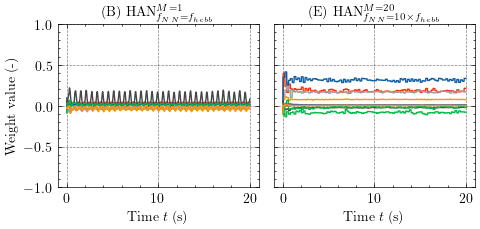

In [38]:
num_neurons = 10
selection_seed = 2
np.random.seed(selection_seed)

# Limit cycle attractor
layers = policy_params_hist_lca[0]["kernel_params"].keys()
indices = []
for _ in range(num_neurons):
    selected_layer = np.random.choice(list(layers))
    array_shape = policy_params_hist_lca[0]["kernel_params"][selected_layer][
        "W"
    ].shape

    # Random indices
    ind_1 = np.random.randint(0, array_shape[0] - 1)
    ind_2 = np.random.randint(0, array_shape[1] - 1)

    indices.append((selected_layer, ind_1, ind_2))

neuron_ts = []
for i in indices:
    neuron_signal = []
    for t in range(len(policy_params_hist_lca)):
        neuron_signal.append(
            policy_params_hist_lca[t]["kernel_params"][i[0]]["W"][i[1], i[2]]
        )

    neuron_ts.append(neuron_signal)

single_weight_history_lca = np.array(neuron_ts)

# Fixed-point attractor
layers = policy_params_hist_fpa[0]["kernel_params"].keys()
indices = []
for _ in range(num_neurons):
    selected_layer = np.random.choice(list(layers))
    array_shape = policy_params_hist_fpa[0]["kernel_params"][selected_layer][
        "W"
    ].shape

    # Random indices
    ind_1 = np.random.randint(0, array_shape[0] - 1)
    ind_2 = np.random.randint(0, array_shape[1] - 1)

    indices.append((selected_layer, ind_1, ind_2))

neuron_ts = []
for i in indices:
    neuron_signal = []
    for t in range(len(policy_params_hist_fpa)):
        neuron_signal.append(
            policy_params_hist_fpa[t]["kernel_params"][i[0]]["W"][i[1], i[2]]
        )

    neuron_ts.append(neuron_signal)

single_weight_history_fpa = np.array(neuron_ts)

# Plotting the weights
t = np.arange(episode_length + 1) * env.dt

fig, axs = plt.subplots(1, 2, figsize=(5.0, 2.5), sharey=True)
axs[0].plot(t, single_weight_history_lca.T)
axs[1].plot(t, single_weight_history_fpa.T)

for ax in axs:
    ax.set_xlabel("Time $t$ (s)")
    ax.set_ylim(-1.0, 1.0)

axs[0].set_title(r"(B) HAN$^{M=1}_{f_{NN}=f_{hebb}}$", fontsize=10)
axs[1].set_title(r"(E) HAN$^{M=20}_{f_{NN}=10 \times f_{hebb}}$", fontsize=10)
axs[0].set_ylabel("Weight value (-)")

fig.tight_layout()
plt.show()

### Animations

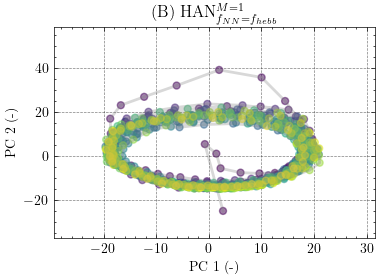

LCA PCA animation saved as quadruped_pca_lca_animation.gif


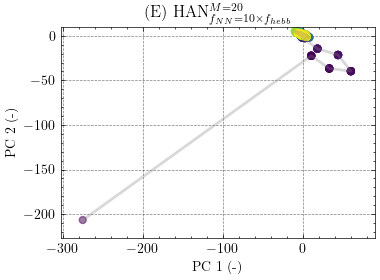

FPA PCA animation saved as quadruped_pca_fpa_animation.gif


In [40]:
import matplotlib.animation as animation

# Create animated PCA visualization for quadruped locomotion


# Animation for Limit Cycle Attractor (LCA)
def create_lca_pca_animation():
    fig, ax = plt.subplots(figsize=(4, 3))

    # Set up the plot
    ax.set_xlabel("PC 1 (-)")
    ax.set_ylabel("PC 2 (-)")
    ax.set_title(r"(B) HAN$^{M=1}_{f_{NN}=f_{hebb}}$")
    ax.grid(True)

    # Set axis limits with some padding
    ax.set_xlim(
        pca_history_lca[:, 0].min() * 1.5, pca_history_lca[:, 0].max() * 1.5
    )
    ax.set_ylim(
        pca_history_lca[:, 1].min() * 1.5, pca_history_lca[:, 1].max() * 1.5
    )

    fig.tight_layout()

    # Initialize empty line and scatter plot
    (line,) = ax.plot([], [], color="grey", alpha=0.3, linewidth=2)

    # Time array for colors
    t = np.arange(episode_length + 1) * env.dt
    cmap = cm.viridis
    norm = mcolors.Normalize(vmin=t[0], vmax=t[-1])

    # Skip frames to reduce file size
    frame_skip = 5
    frame_indices = list(range(0, len(pca_history_lca), frame_skip))

    def animate(frame):
        if frame < len(pca_history_lca):
            # Update trajectory line
            line.set_data(
                pca_history_lca[: frame + 1, 0],
                pca_history_lca[: frame + 1, 1],
            )

            # Clear previous scatter points
            for collection in ax.collections[:]:
                collection.remove()

            # Add scatter points up to current frame
            if frame > 0:
                ax.scatter(
                    pca_history_lca[: frame + 1, 0],
                    pca_history_lca[: frame + 1, 1],
                    alpha=0.5,
                    c=t[: frame + 1],
                    cmap=cmap,
                    s=25,
                    norm=norm,
                )

        return [line]

    # Create animation
    anim = animation.FuncAnimation(
        fig,
        animate,
        frames=frame_indices,
        interval=50,
        blit=False,
        repeat=True,
    )

    # Save and show
    anim.save(
        "plots/quadruped_pca_lca_animation.gif",
        writer="pillow",
        fps=10,
        dpi=100,
    )

    plt.show()
    print("LCA PCA animation saved as quadruped_pca_lca_animation.gif")

    return anim


# Animation for Fixed Point Attractor (FPA)
def create_fpa_pca_animation():
    fig, ax = plt.subplots(figsize=(4, 3))

    # Set up the plot
    ax.set_xlabel("PC 1 (-)")
    ax.set_ylabel("PC 2 (-)")
    ax.set_title(r"(E) HAN$^{M=20}_{f_{NN}=10 \times f_{hebb}}$")
    ax.grid(True)

    # Set axis limits with some padding
    ax.set_xlim(
        pca_history_fpa[:, 0].min() * 1.1, pca_history_fpa[:, 0].max() * 1.5
    )
    ax.set_ylim(
        pca_history_fpa[:, 1].min() * 1.1, pca_history_fpa[:, 1].max() * 2.0
    )

    fig.tight_layout()

    # Initialize empty line and scatter plot
    (line,) = ax.plot([], [], color="grey", alpha=0.3, linewidth=2)

    # Time array for colors
    t = np.arange(episode_length + 1) * env.dt
    cmap = cm.viridis
    norm = mcolors.Normalize(vmin=t[0], vmax=t[-1])

    # Skip frames to reduce file size
    frame_skip = 5
    frame_indices = list(range(0, len(pca_history_fpa), frame_skip))

    def animate(frame):
        if frame < len(pca_history_fpa):
            # Update trajectory line
            line.set_data(
                pca_history_fpa[: frame + 1, 0],
                pca_history_fpa[: frame + 1, 1],
            )

            # Clear previous scatter points
            for collection in ax.collections[:]:
                collection.remove()

            # Add scatter points up to current frame
            if frame > 0:
                ax.scatter(
                    pca_history_fpa[: frame + 1, 0],
                    pca_history_fpa[: frame + 1, 1],
                    alpha=0.5,
                    c=t[: frame + 1],
                    cmap=cmap,
                    s=25,
                    norm=norm,
                )

        return [line]

    # Create animation
    anim = animation.FuncAnimation(
        fig,
        animate,
        frames=frame_indices,
        interval=50,
        blit=False,
        repeat=True,
    )

    # Save and show
    anim.save(
        "plots/quadruped_pca_fpa_animation.gif",
        writer="pillow",
        fps=10,
        dpi=100,
    )
    plt.show()
    print("FPA PCA animation saved as quadruped_pca_fpa_animation.gif")

    return anim


# Create both animations
lca_anim = create_lca_pca_animation()
fpa_anim = create_fpa_pca_animation()